# 1. Dependencies 

## Notes for Sureksha:
- I created functions to load well files ( a single horizontal file, randomly, with its corresponding Typwell file )
- I then analysed the datasets with .info(), .describe() etc
- plotted to visualise

## GR shape comparison — Typewell vs Horizontal well

This plots GR vs TVT (typewell) and GR vs MD (horizontal well) side by side, normalized
onto the same 0–1 axis just to visually check that the two GR curves look similar in shape.

<div style="background-color:#e6f4ea; border-left:5px solid #34a853; padding:10px; border-radius:4px;">
<b>TODO (next step):</b> Write a function that slides a window of the horizontal well's GR values
across the typewell's GR curve, scores how well each position matches, and finds the
best-matching TVT for each MD. That matched TVT (+ ideally a confidence/correlation score)
becomes an <b>engineered feature</b> — an input the model uses, alongside GR, XYZ, etc. —
to help predict the actual TVT for the masked/unseen part of the well. 

🛎️ Ping me if still not clear, or if you want to propose a different way or additional step before this ;)
</div>

In [1]:
# import all libraries and functions here ...
import pandas as pd 
import os
import glob
import random 
import matplotlib.pyplot as plt

# 2. Exploratory Data Analysis 

In [2]:
# constants
#directories
DATA_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

#files
HORIZONTAL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__horizontal_well.csv"))
TYPEWELL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__typewell.csv"))

In [3]:
# code to see all files in the data/ input directory 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [4]:
# check horizontal csv file 
def get_horizontal_file():
    file_path = random.choice(HORIZONTAL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df, well_ID

In [5]:
# check typewell csv file 
def get_typewell_file():
    file_path = random.choice(TYPEWELL_FILES)
    df = pd.read_csv(file_path)
    well_ID = ps.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df 

In [6]:
# get matching typewell file 
def get_matching_files():
    horizontal_df, well_ID  = get_horizontal_file()
    typewell_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    typewell_df = pd.read_csv(typewell_file)
    return horizontal_df, well_ID,typewell_df

In [7]:
h_df, ID , tw_df = get_matching_files()

In [8]:
h_df.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,11051.0,2980092.17,1051773.90,-8863.46,-9703.44,-9897.36,-9899.12,-9963.64,-9998.34,-10149.84,11031.88,96.999743,11031.88,61f27424
1,11052.0,2980092.16,1051773.89,-8864.46,-9703.44,-9897.36,-9899.12,-9963.64,-9998.34,-10149.84,11032.88,101.455852,11032.88,61f27424
2,11053.0,2980092.16,1051773.89,-8865.46,-9703.44,-9897.36,-9899.12,-9963.64,-9998.34,-10149.84,11033.88,84.266542,11033.88,61f27424
3,11054.0,2980092.15,1051773.88,-8866.46,-9703.44,-9897.36,-9899.13,-9963.64,-9998.34,-10149.84,11034.88,87.882648,11034.88,61f27424
4,11055.0,2980092.15,1051773.88,-8867.46,-9703.44,-9897.36,-9899.13,-9963.64,-9998.34,-10149.84,11035.87,92.297781,11035.87,61f27424


In [9]:
tw_df.head()

,TVT,GR,Geology
0,11019.45,103.08,NaN
1,11019.95,99.05,NaN
2,11020.45,98.10,NaN
3,11020.95,100.54,NaN
4,11021.45,106.76,NaN


In [10]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         8341 non-null   float64
 1   X          8341 non-null   float64
 2   Y          8341 non-null   float64
 3   Z          8341 non-null   float64
 4   ANCC       8341 non-null   float64
 5   ASTNU      8341 non-null   float64
 6   ASTNL      8341 non-null   float64
 7   EGFDU      8341 non-null   float64
 8   EGFDL      8341 non-null   float64
 9   BUDA       8341 non-null   float64
 10  TVT        8341 non-null   float64
 11  GR         7653 non-null   float64
 12  TVT_input  2121 non-null   float64
 13  WELL_ID    8341 non-null   object 
dtypes: float64(13), object(1)
memory usage: 912.4+ KB


In [11]:
h_df.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,8341.000000,8.341000e+03,8.341000e+03,8341.000000,8341.000000,8341.000000,8341.000000,8341.000000,8341.000000,8341.000000,8341.000000,7653.000000,2121.000000
mean,15221.000000,2.980062e+06,1.055264e+06,-9768.934507,-9575.198209,-9769.118941,-9770.884213,-9835.398209,-9870.098209,-10021.598209,12065.585441,73.108800,11830.133932
std,2407.983631,2.754987e+01,2.349107e+03,192.379225,79.889680,79.889660,79.889612,79.889680,79.889680,79.889680,224.746907,15.832679,352.575546
min,11051.000000,2.980013e+06,1.051774e+06,-9932.050000,-9703.460000,-9897.380000,-9899.140000,-9963.660000,-9998.360000,-10149.860000,11031.880000,31.192757,11031.880000
25%,13136.000000,2.980041e+06,1.053144e+06,-9879.830000,-9643.650000,-9837.570000,-9839.330000,-9903.850000,-9938.550000,-10090.050000,12141.190000,63.471371,11560.000000
50%,15221.000000,2.980052e+06,1.055227e+06,-9811.880000,-9569.790000,-9763.710000,-9765.480000,-9829.990000,-9864.690000,-10016.190000,12146.080000,70.478217,11991.130000
75%,17306.000000,2.980089e+06,1.057310e+06,-9747.080000,-9509.230000,-9703.160000,-9704.920000,-9769.430000,-9804.130000,-9955.630000,12147.180000,76.593841,12141.700000
max,19391.000000,2.980121e+06,1.059393e+06,-8863.460000,-9438.470000,-9632.390000,-9634.150000,-9698.670000,-9733.370000,-9884.870000,12151.050000,167.488204,12146.660000


In [12]:
tw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2799 entries, 0 to 2798
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      2799 non-null   float64
 1   GR       2799 non-null   float64
 2   Geology  1094 non-null   object 
dtypes: float64(2), object(1)
memory usage: 65.7+ KB


In [13]:
tw_df['Geology']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
2794    BUDA
2795    BUDA
2796    BUDA
2797    BUDA
2798    BUDA
Name: Geology, Length: 2799, dtype: object

In [14]:
# another well 
h_df_1, _, tw_df_1 = get_matching_files()

In [15]:
h_df_1.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10362.0,3008450.52,1129260.20,-8283.11,-8677.19,-8786.17,-8884.06,-9046.04,-9096.43,-9202.02,10165.10,NaN,10165.10,656a067b
1,10363.0,3008450.50,1129260.22,-8284.11,-8676.53,-8785.51,-8883.40,-9045.38,-9095.77,-9201.36,10166.76,NaN,10166.76,656a067b
2,10364.0,3008450.47,1129260.25,-8285.11,-8675.87,-8784.85,-8882.74,-9044.72,-9095.11,-9200.70,10168.42,NaN,10168.42,656a067b
3,10365.0,3008450.45,1129260.27,-8286.11,-8675.21,-8784.19,-8882.08,-9044.06,-9094.45,-9200.04,10170.08,NaN,10170.08,656a067b
4,10366.0,3008450.43,1129260.30,-8287.11,-8674.55,-8783.53,-8881.42,-9043.40,-9093.79,-9199.38,10171.74,NaN,10171.74,656a067b


In [16]:
h_df_1.shape

(4896, 14)

In [17]:
h_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4896 entries, 0 to 4895
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         4896 non-null   float64
 1   X          4896 non-null   float64
 2   Y          4896 non-null   float64
 3   Z          4896 non-null   float64
 4   ANCC       4896 non-null   float64
 5   ASTNU      4896 non-null   float64
 6   ASTNL      4896 non-null   float64
 7   EGFDU      4896 non-null   float64
 8   EGFDL      4896 non-null   float64
 9   BUDA       4896 non-null   float64
 10  TVT        4896 non-null   float64
 11  GR         3957 non-null   float64
 12  TVT_input  1845 non-null   float64
 13  WELL_ID    4896 non-null   object 
dtypes: float64(13), object(1)
memory usage: 535.6+ KB


In [18]:
tw_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1940 entries, 0 to 1939
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      1940 non-null   float64
 1   GR       1940 non-null   float64
 2   Geology  1127 non-null   object 
dtypes: float64(2), object(1)
memory usage: 45.6+ KB


In [19]:
def plot_x_y(x, y, x_label , y_label, title):
    plt.figure(figsize = (20,8))
    plt.plot(x, y, linewidth = 0.8)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha = 0.3)
    plt.show()

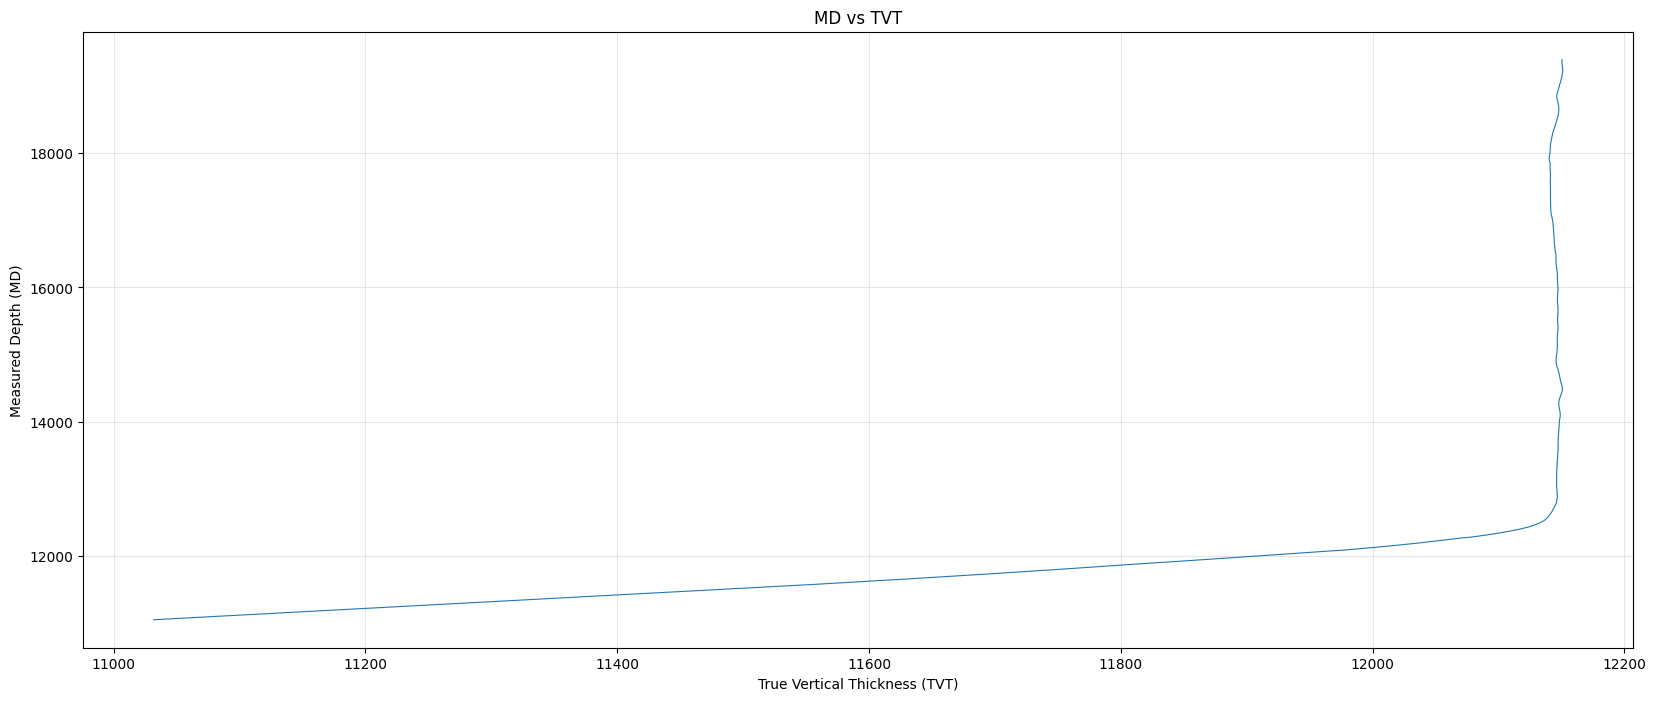

In [20]:
# MD against TVT 
# illustrates where the horizontal drilling starts (?)
plot_x_y(h_df['TVT'], h_df['MD'], "True Vertical Thickness (TVT)", "Measured Depth (MD)", "MD vs TVT")

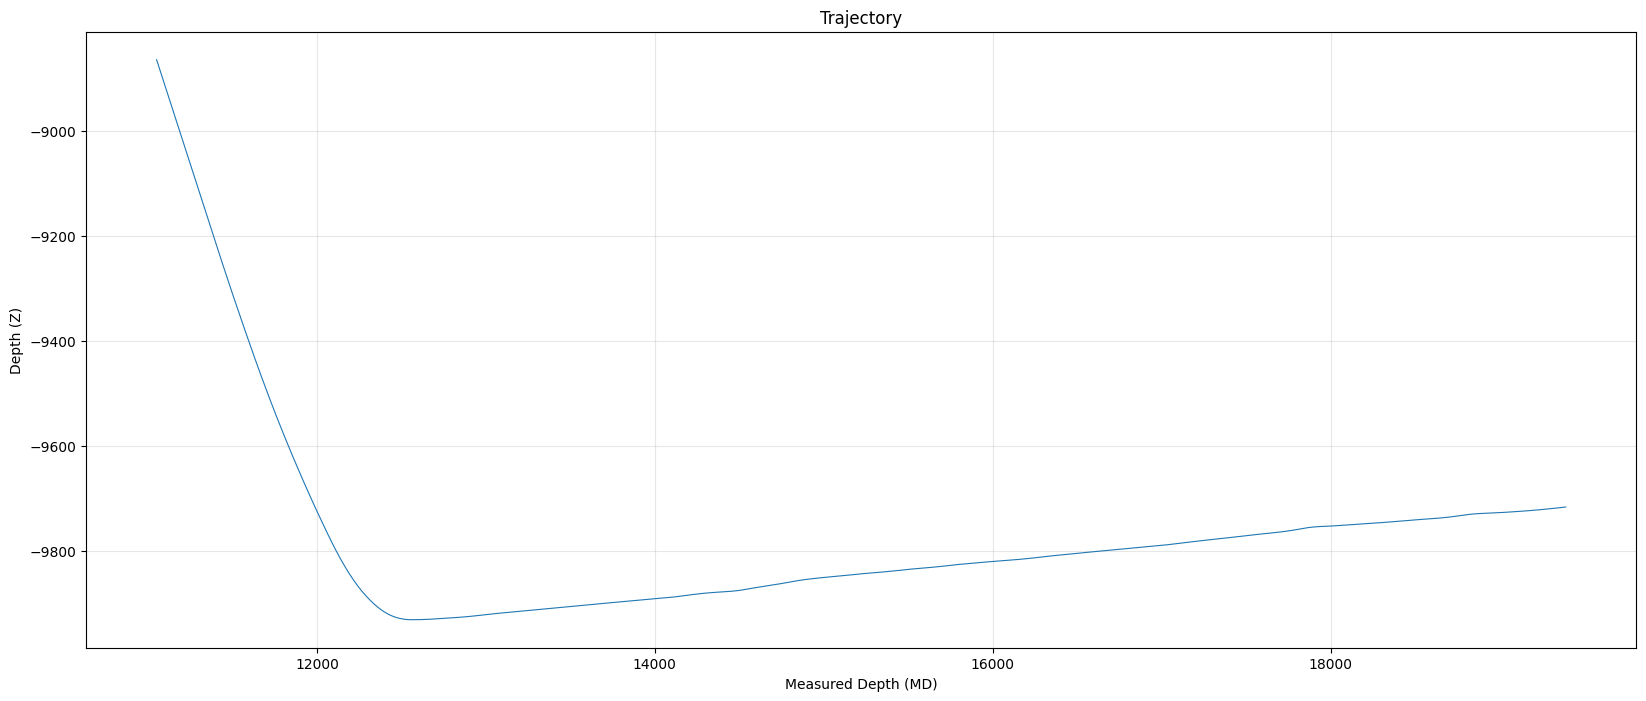

In [21]:
# y against x 
plot_x_y(h_df['MD'], h_df['Z'], "Measured Depth (MD)", "Depth (Z)", "Trajectory")

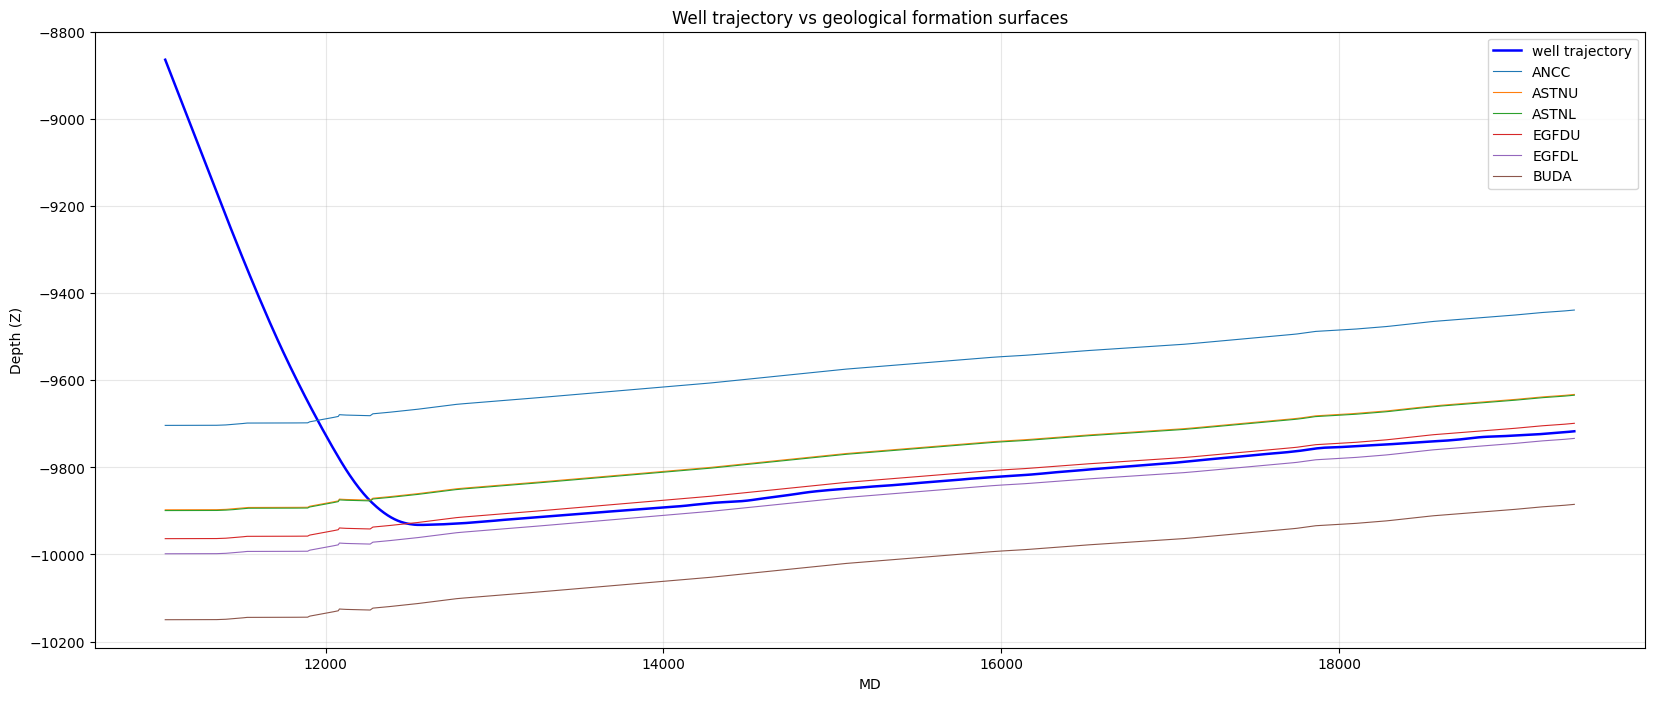

In [22]:
plt.figure(figsize=(20, 8))
plt.plot(h_df['MD'], h_df['Z'], linewidth=1.8, label='well trajectory', color='blue')
plt.plot(h_df['MD'], h_df['ANCC'], linewidth=0.8, label='ANCC')
plt.plot(h_df['MD'], h_df['ASTNU'], linewidth=0.8, label='ASTNU')
plt.plot(h_df['MD'], h_df['ASTNL'], linewidth=0.8, label='ASTNL')
plt.plot(h_df['MD'], h_df['EGFDU'], linewidth=0.8, label='EGFDU')
plt.plot(h_df['MD'], h_df['EGFDL'], linewidth=0.8, label='EGFDL')
plt.plot(h_df['MD'], h_df['BUDA'], linewidth=0.8, label='BUDA')
plt.xlabel("MD")
plt.ylabel("Depth (Z)")
plt.title("Well trajectory vs geological formation surfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

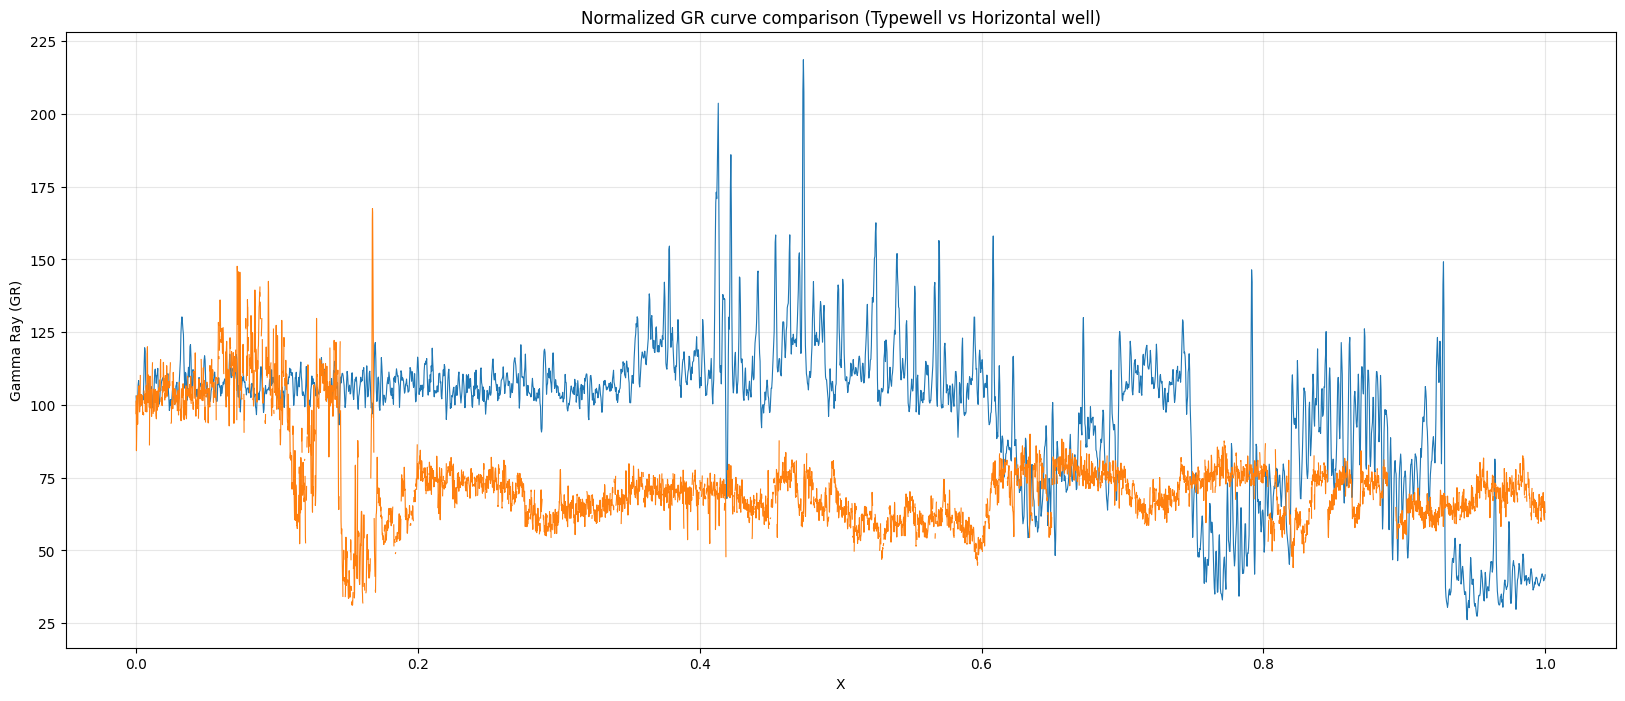

In [23]:
# Quick visual check: do the two GR curves have a similar shape/pattern?
# This does NOT find the actual TVT match — it's just eyeballing texture before
# building the real sliding-window correlation function.

# normalising for a cleaner look 
tw_norm = (tw_df['TVT']- tw_df['TVT'].min())/ (tw_df['TVT'].max() - tw_df['TVT'].min())
h_norm = (h_df['MD'] - h_df['MD'].min()) / (h_df['MD'].max() - h_df['MD'].min())

#plotting 
plt.figure(figsize = (20,8))
plt.plot(tw_norm, tw_df['GR'], linewidth = 0.8 , label = 'Typewell GR')
plt.plot(h_norm, h_df['GR'], linewidth = 0.8, label = 'Horizontal Well GR')
plt.xlabel("X")
plt.ylabel("Gamma Ray (GR)")
plt.title("Normalized GR curve comparison (Typewell vs Horizontal well)")
plt.grid(True, alpha = 0.3)
plt.show()


In [24]:
# TODO: use scipy.signal.correlate (or similar) to find the best-matching
# offset between h_df['GR'] and tw_df['GR'], then map each MD to its matched TVT.

# 3. Data Cleaning 

# 4. Feature Engineering

# 5. Modeling

# 6. Evaluation